In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path = 'climate_change_impact_on_agriculture_2024.csv'
data = pd.read_csv(file_path)
# Display the first few rows of the dataset
data.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  object 
 2   Region                       10000 non-null  object 
 3   Crop_Type                    10000 non-null  object 
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strate

In [5]:
data['Crop_Type'].value_counts()

Crop_Type
Wheat         1047
Cotton        1044
Vegetables    1036
Corn          1022
Rice          1022
Sugarcane      995
Fruits         979
Soybeans       958
Barley         952
Coffee         945
Name: count, dtype: int64

In [6]:
data['Country'].value_counts()

Country
Australia    1032
USA          1032
China        1031
Nigeria      1029
India        1025
Canada        984
Argentina     984
France        978
Russia        961
Brazil        944
Name: count, dtype: int64

<Axes: ylabel='count'>

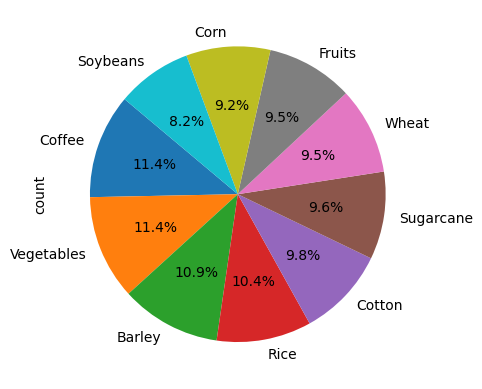

In [7]:
data[data['Country'] == "USA"]["Crop_Type"].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)# crop typs in USA

<Axes: ylabel='count'>

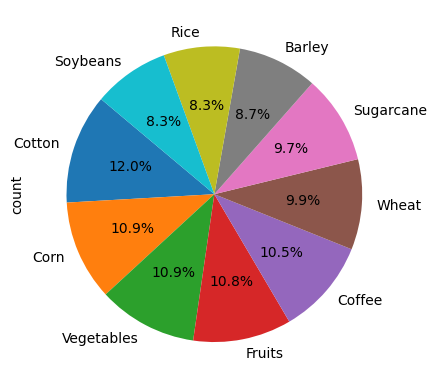

In [8]:
data[data['Country'] == "Australia"]["Crop_Type"].value_counts() .plot.pie(autopct='%1.1f%%', startangle=140)# crop typs in India

<Axes: ylabel='count'>

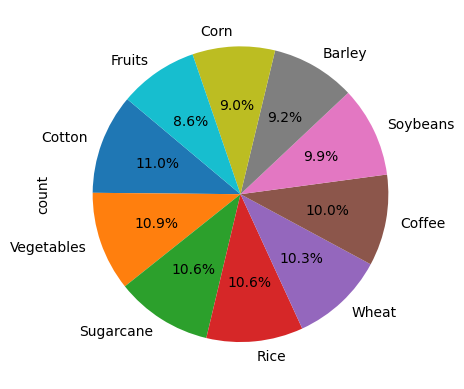

In [9]:
data[data['Country'] == "China"]["Crop_Type"].value_counts() .plot.pie(autopct='%1.1f%%', startangle=140)

In [10]:
data['Crop_Yield_MT_per_HA'].describe()

count    10000.000000
mean         2.240017
std          0.998342
min          0.450000
25%          1.449000
50%          2.170000
75%          2.930000
max          5.000000
Name: Crop_Yield_MT_per_HA, dtype: float64

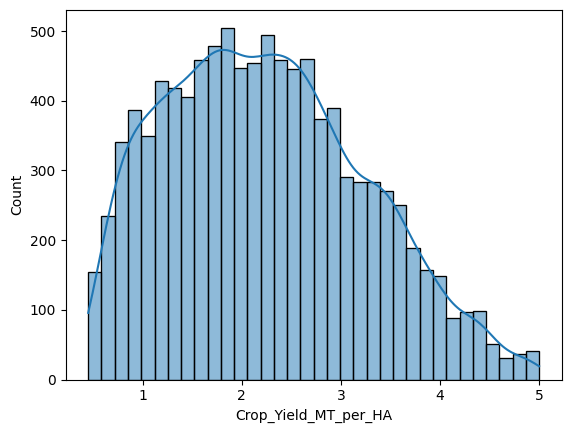

In [11]:
# histogram 

sns.histplot(data['Crop_Yield_MT_per_HA'], kde=True)
plt.show()

Observaciones:
1. Asimetría positiva
2. La mayoría de los valores se concentran entre 1 y 3 toneladas métricas por hectárea (TM/HA)
3. Posibles valores atípicos: Hay relativamente menos observaciones de rendimientos de cultivos superiores a 4 TM/HA.

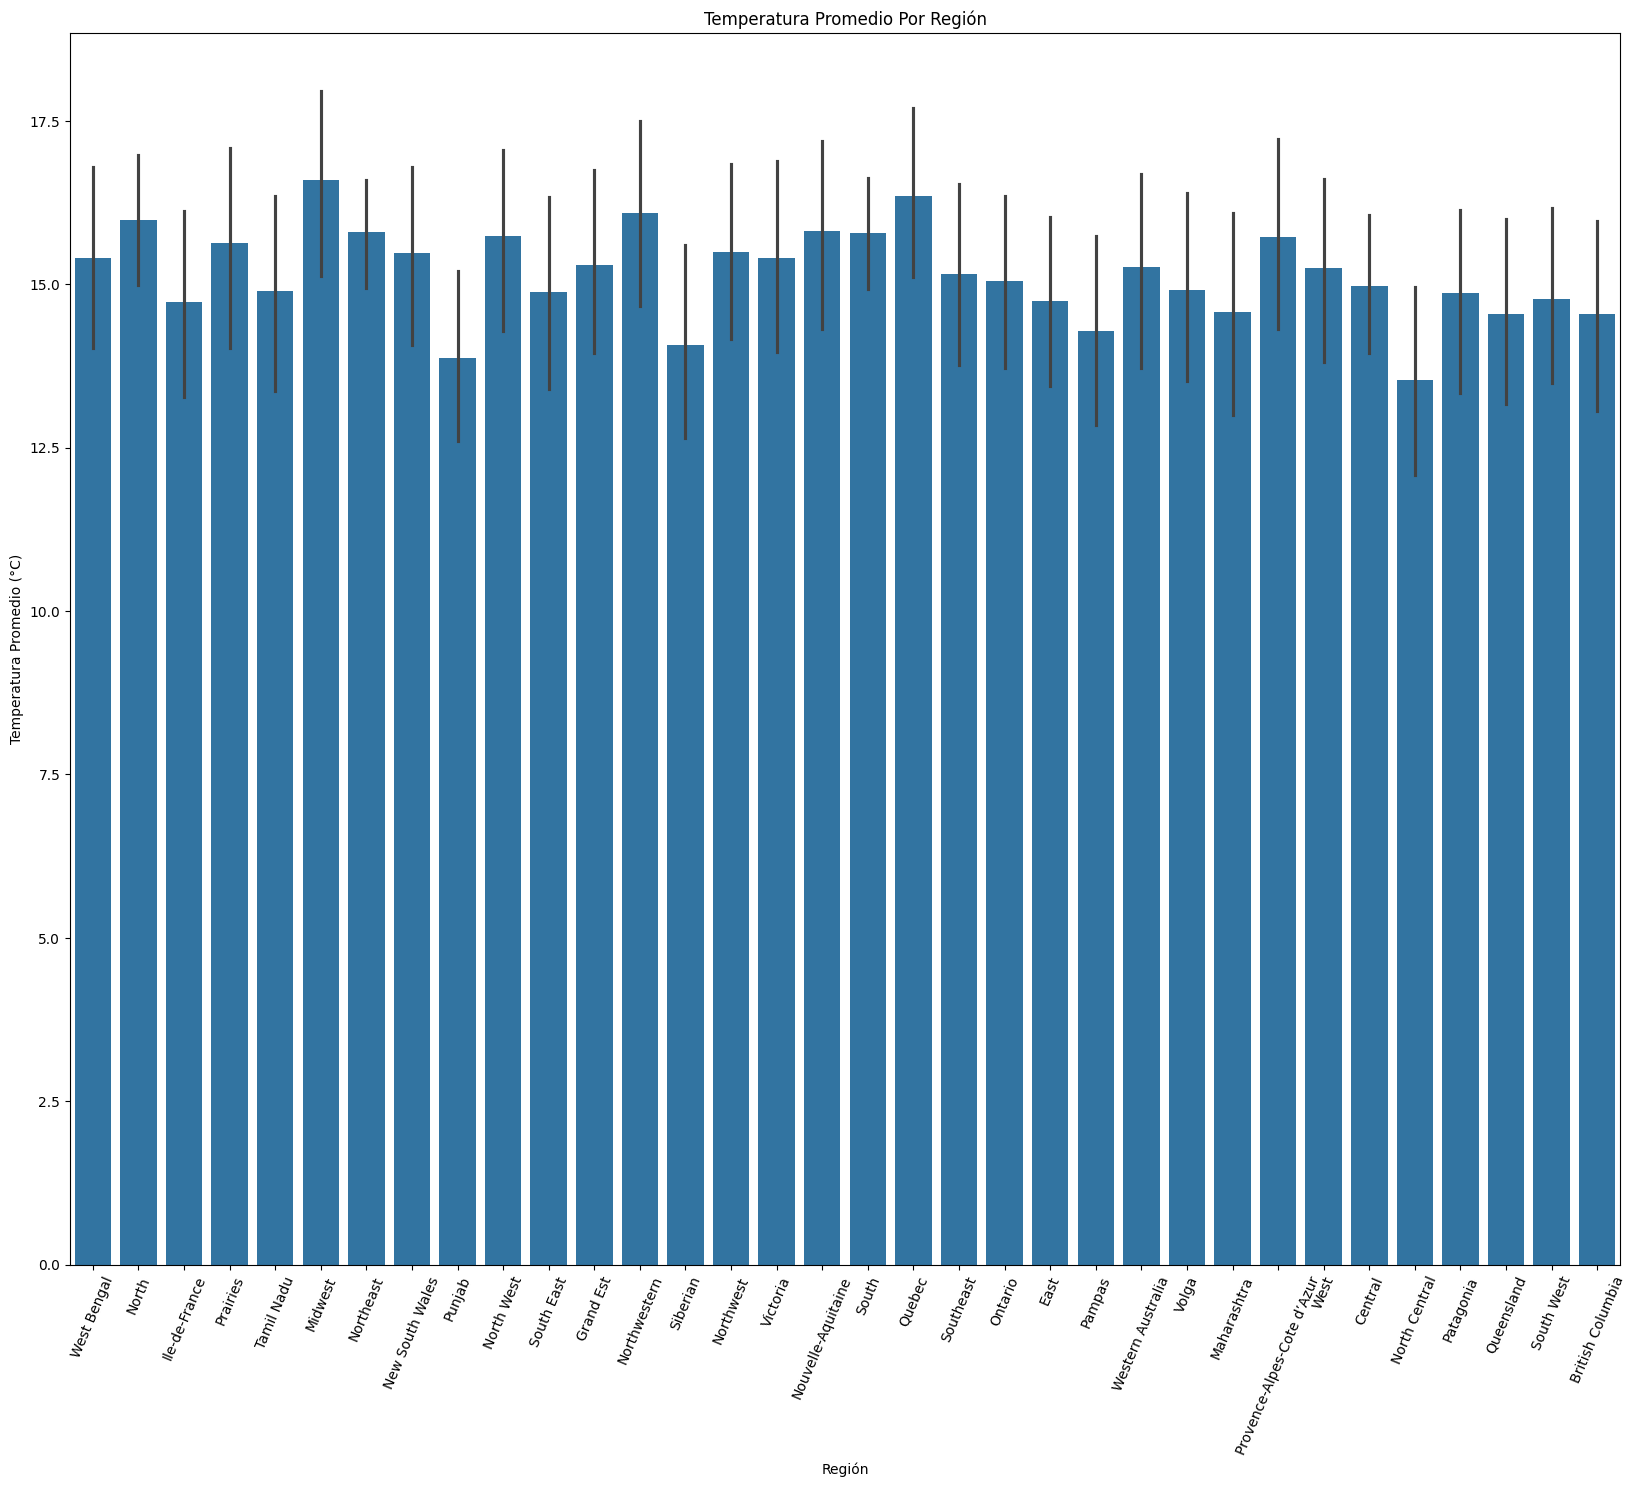

In [12]:
plt.figure(figsize=(20, 16))
sns.barplot(x='Region', y='Average_Temperature_C', data=data, estimator='mean')
plt.title('Temperatura Promedio Por Región')
plt.xlabel('Región')
plt.ylabel('Temperatura Promedio (°C)')
plt.xticks(rotation=67)
plt.show()

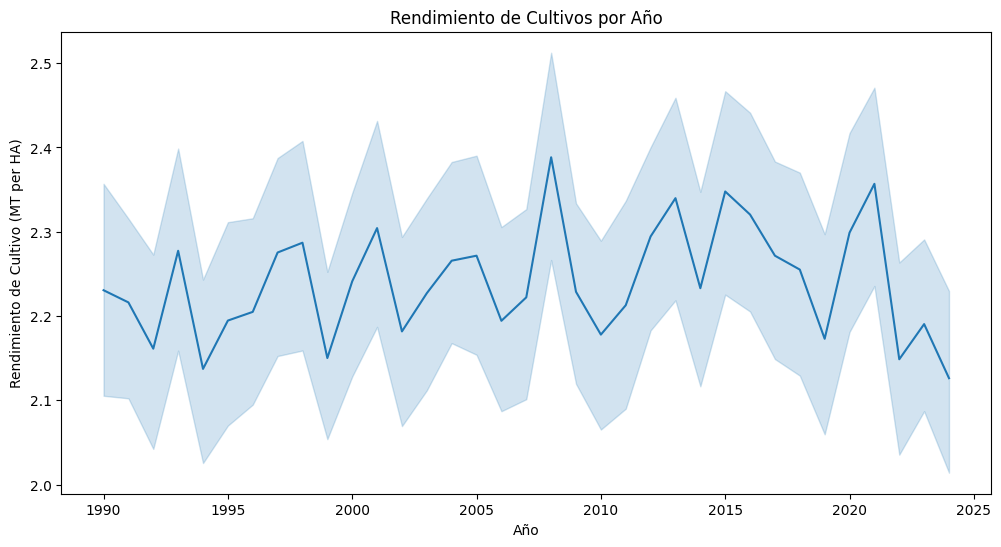

In [13]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Crop_Yield_MT_per_HA', data=data)
plt.title('Rendimiento de Cultivos por Año')
plt.xlabel('Año')
plt.ylabel('Rendimiento de Cultivo (MT per HA)')
plt.show()

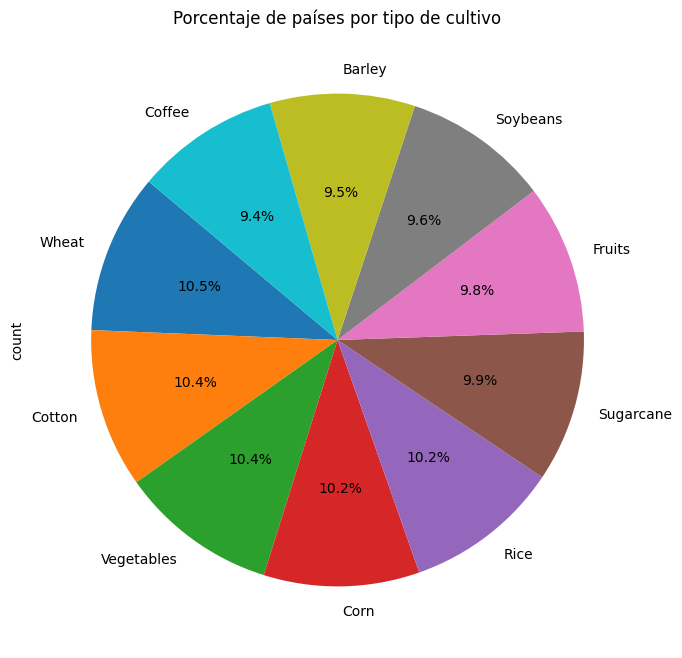

In [14]:
plt.figure(figsize=(8, 8))
data['Crop_Type'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140)
plt.title('Porcentaje de países por tipo de cultivo')
plt.show()


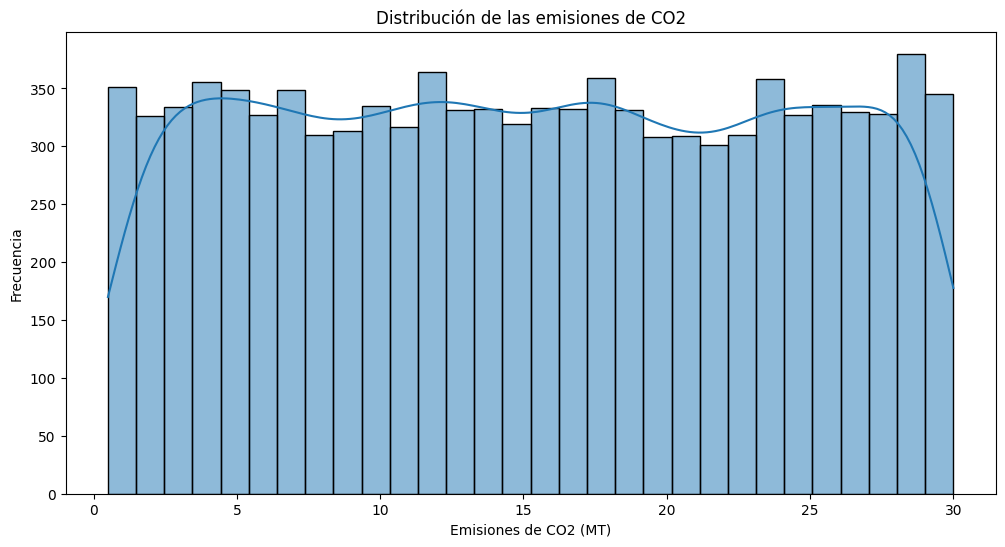

In [15]:
plt.figure(figsize=(12, 6))
sns.histplot(data['CO2_Emissions_MT'], bins=30, kde=True)
plt.title('Distribución de las emisiones de CO2')
plt.xlabel('Emisiones de CO2 (MT)')
plt.ylabel('Frecuencia')
plt.show()

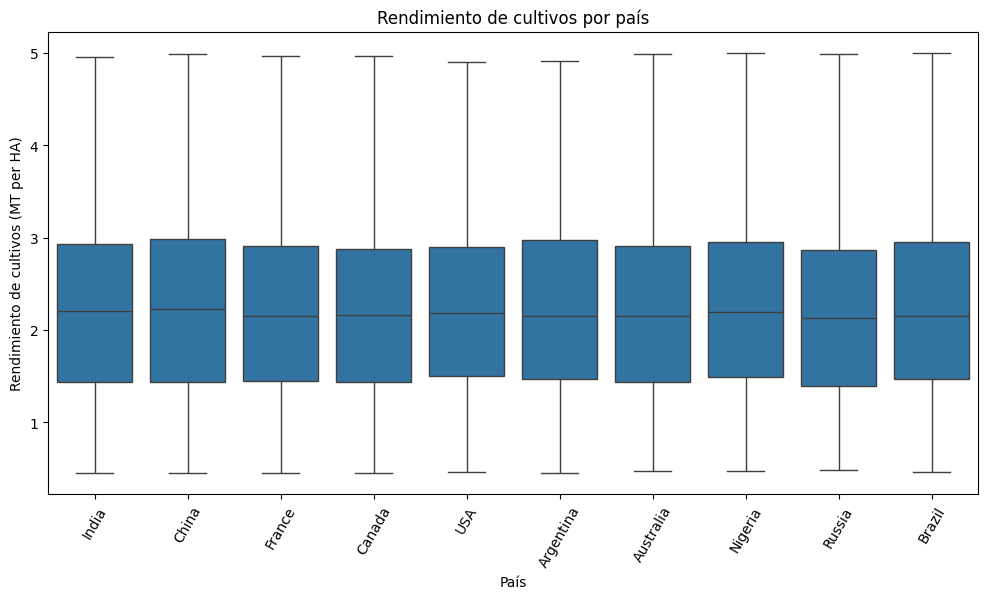

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Country', y='Crop_Yield_MT_per_HA', data=data)
plt.title('Rendimiento de cultivos por país')
plt.xlabel('País')
plt.ylabel('Rendimiento de cultivos (MT per HA)')
plt.xticks(rotation=60)
plt.show()


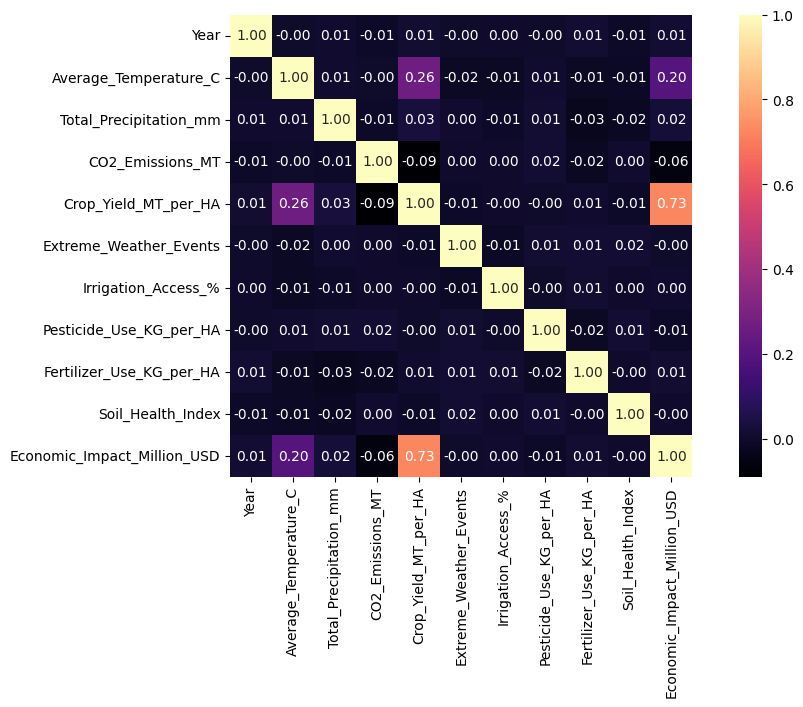

In [17]:
# correlatino matrix 
plt.figure(figsize=(12,6))
corr_mat = data.corr(numeric_only=True) 
sns.heatmap(corr_mat, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, cmap= 'magma')
plt.show()

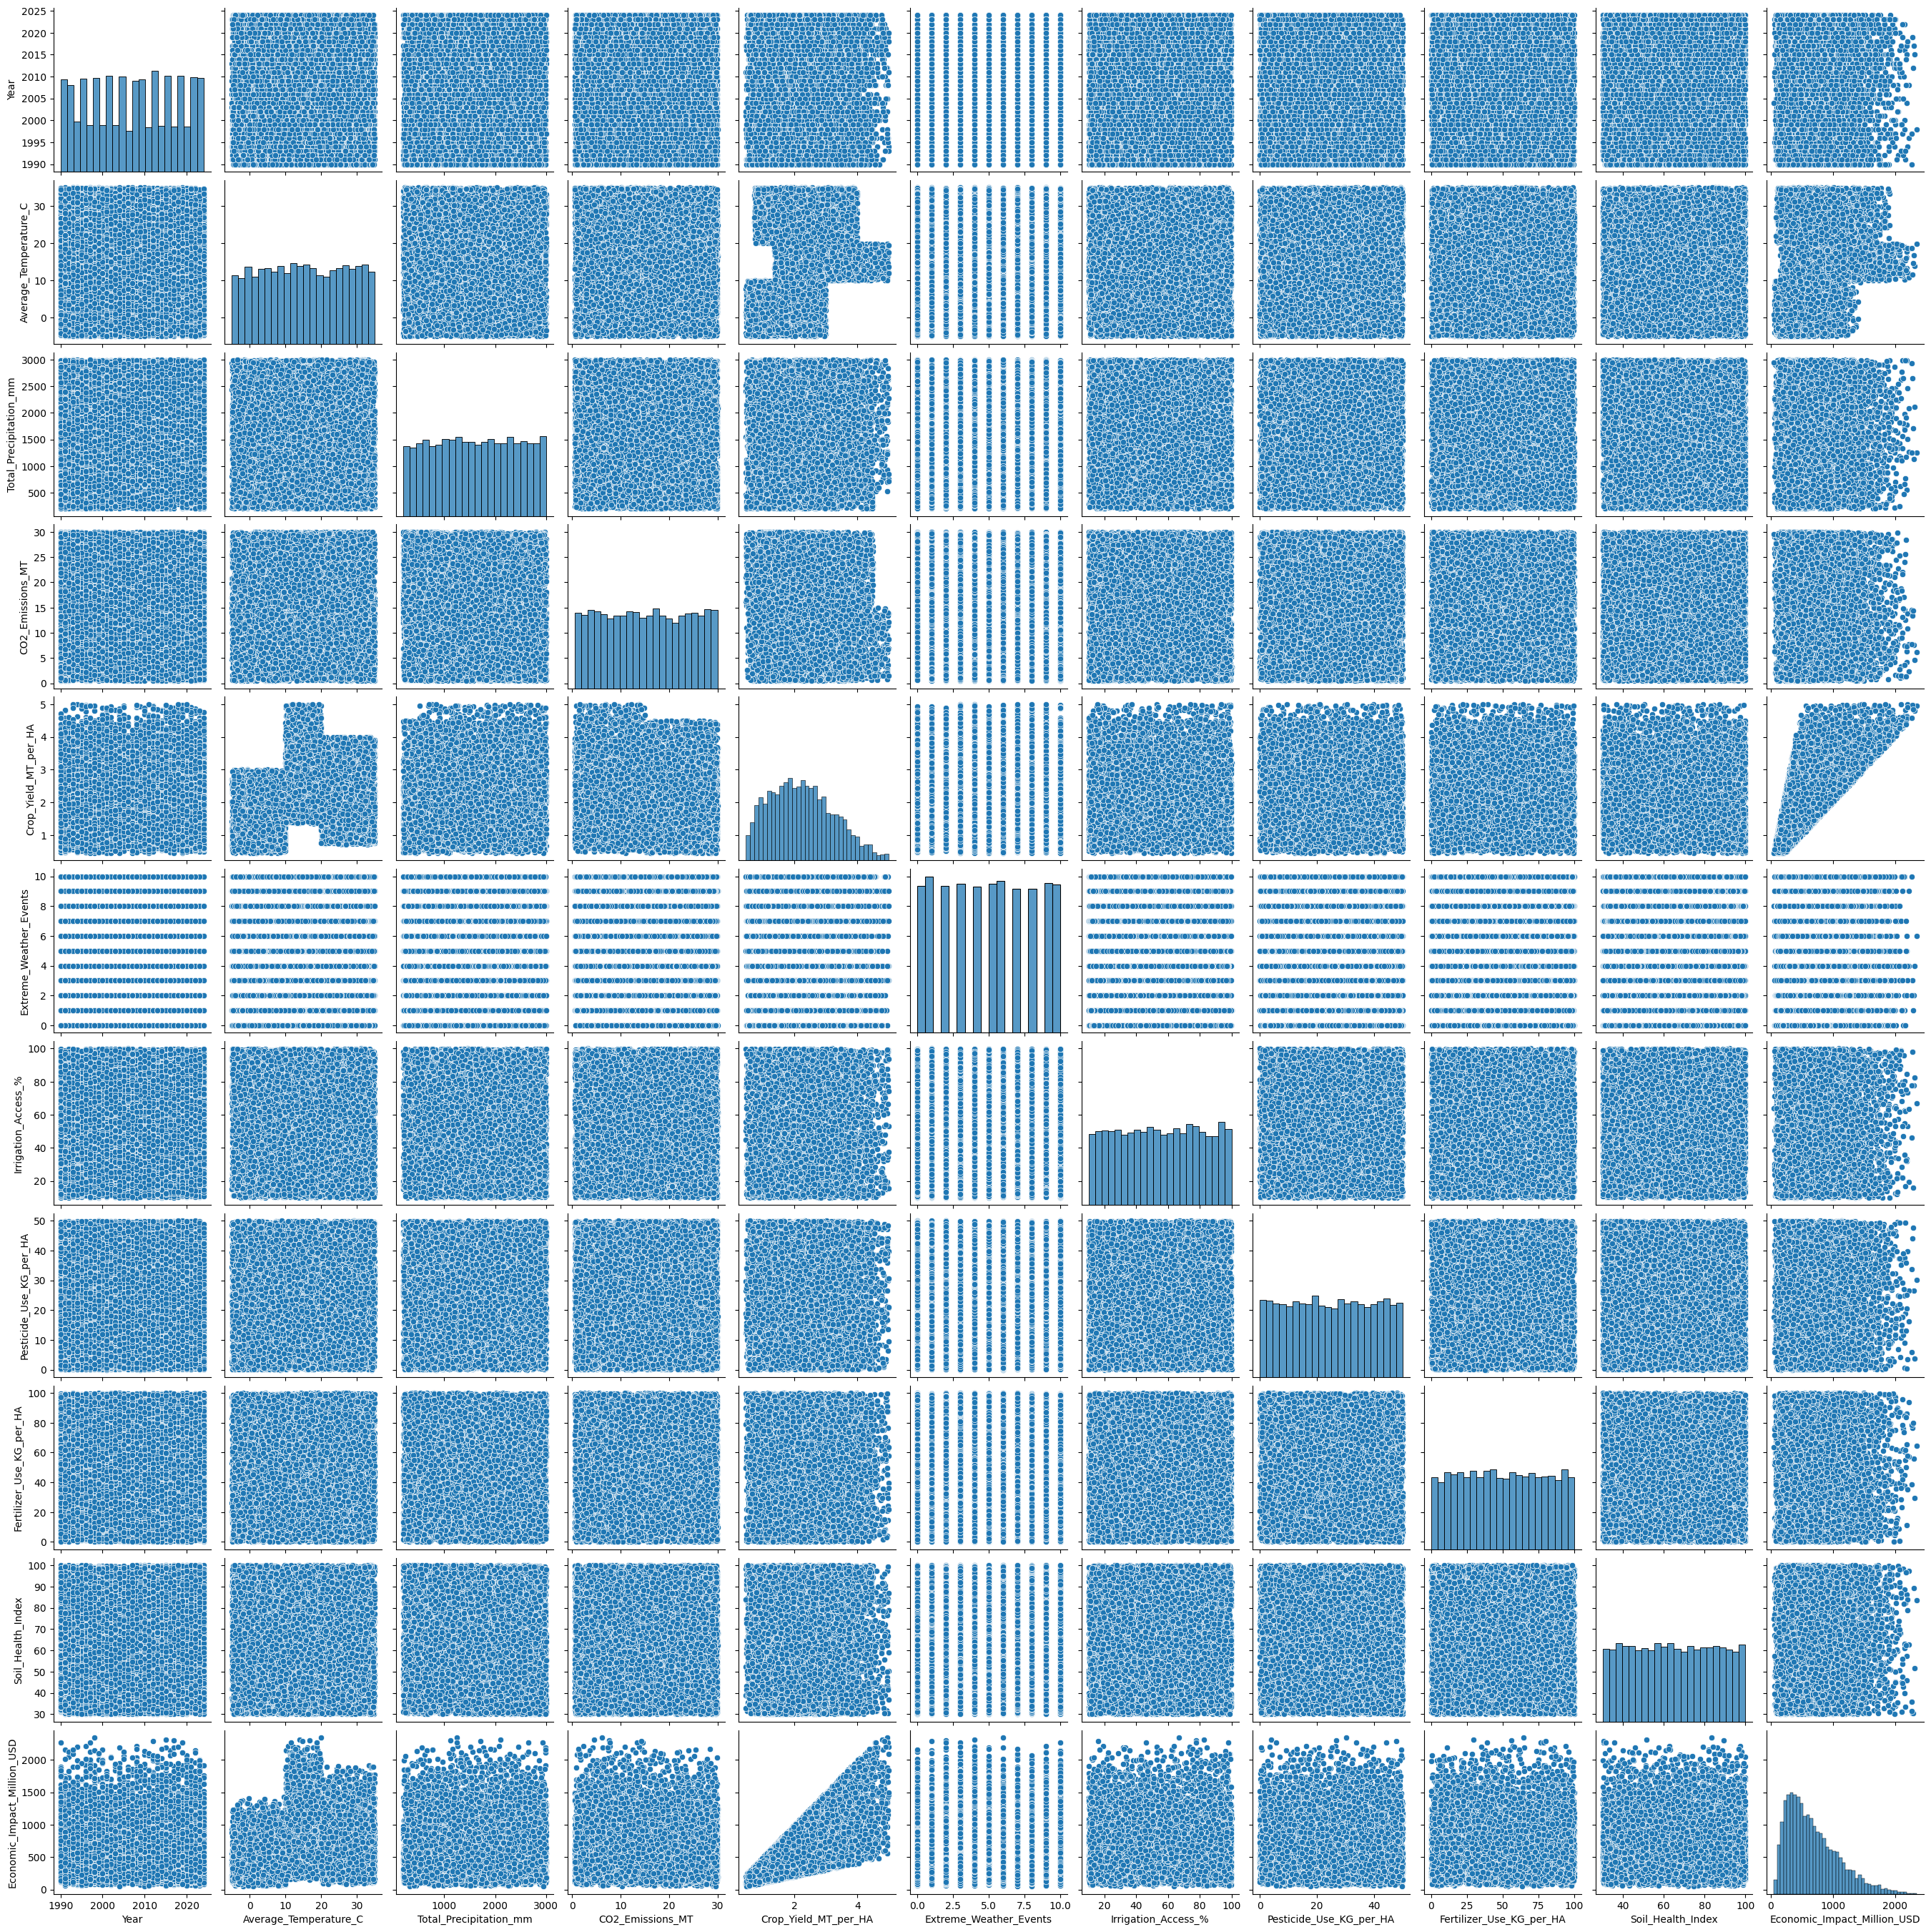

In [18]:
sns.pairplot(data)

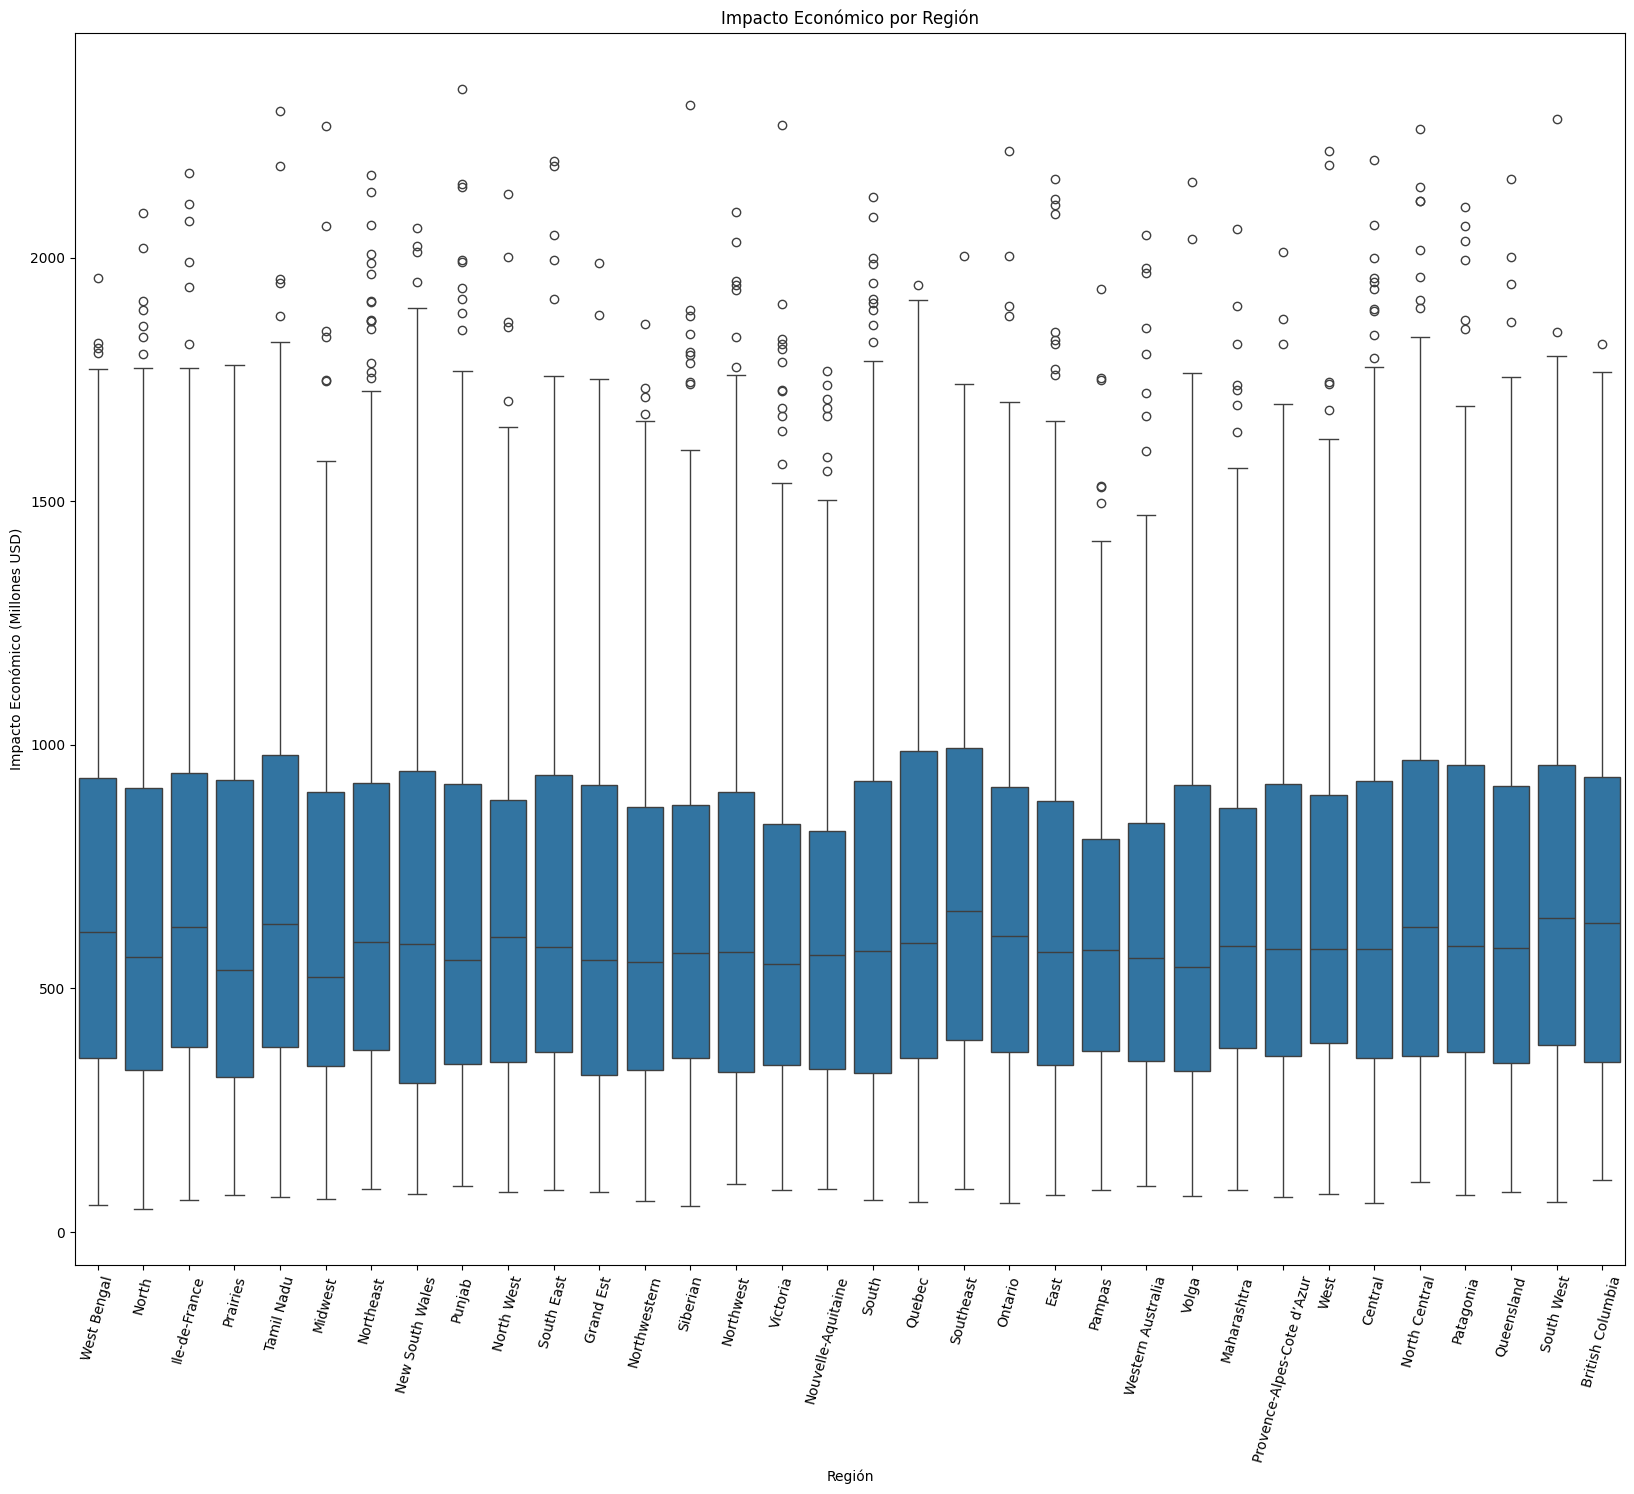

In [19]:
plt.figure(figsize=(20, 16))
sns.boxplot(x='Region', y='Economic_Impact_Million_USD', data=data)
plt.title('Impacto Económico por Región')
plt.xlabel('Región')
plt.ylabel('Impacto Económico (Millones USD)')
plt.xticks(rotation=75)
plt.show()

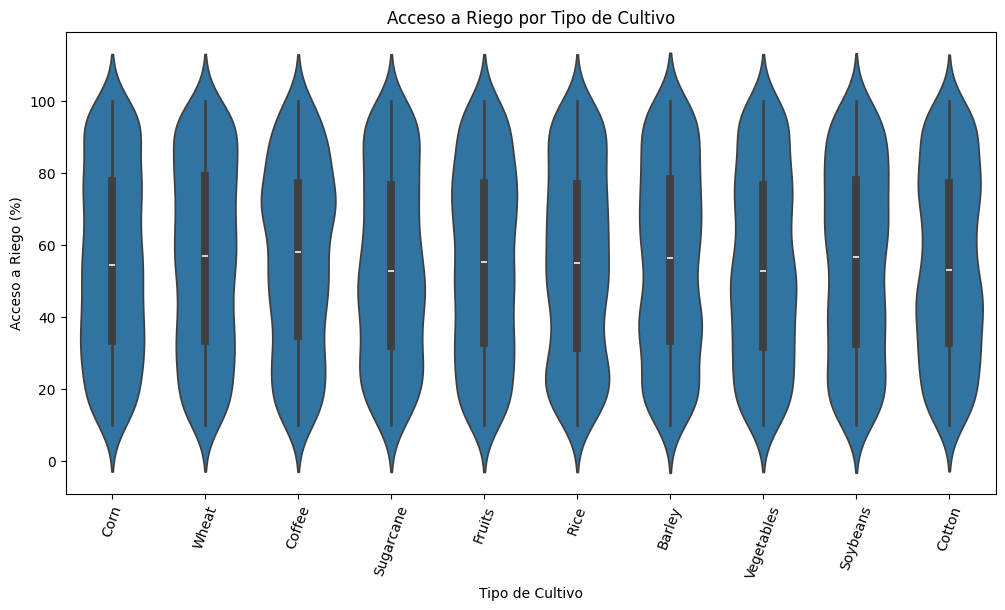

In [20]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='Crop_Type', y='Irrigation_Access_%', data=data)
plt.title('Acceso a Riego por Tipo de Cultivo')
plt.xlabel('Tipo de Cultivo')
plt.ylabel('Acceso a Riego (%)')
plt.xticks(rotation=70)
plt.show()

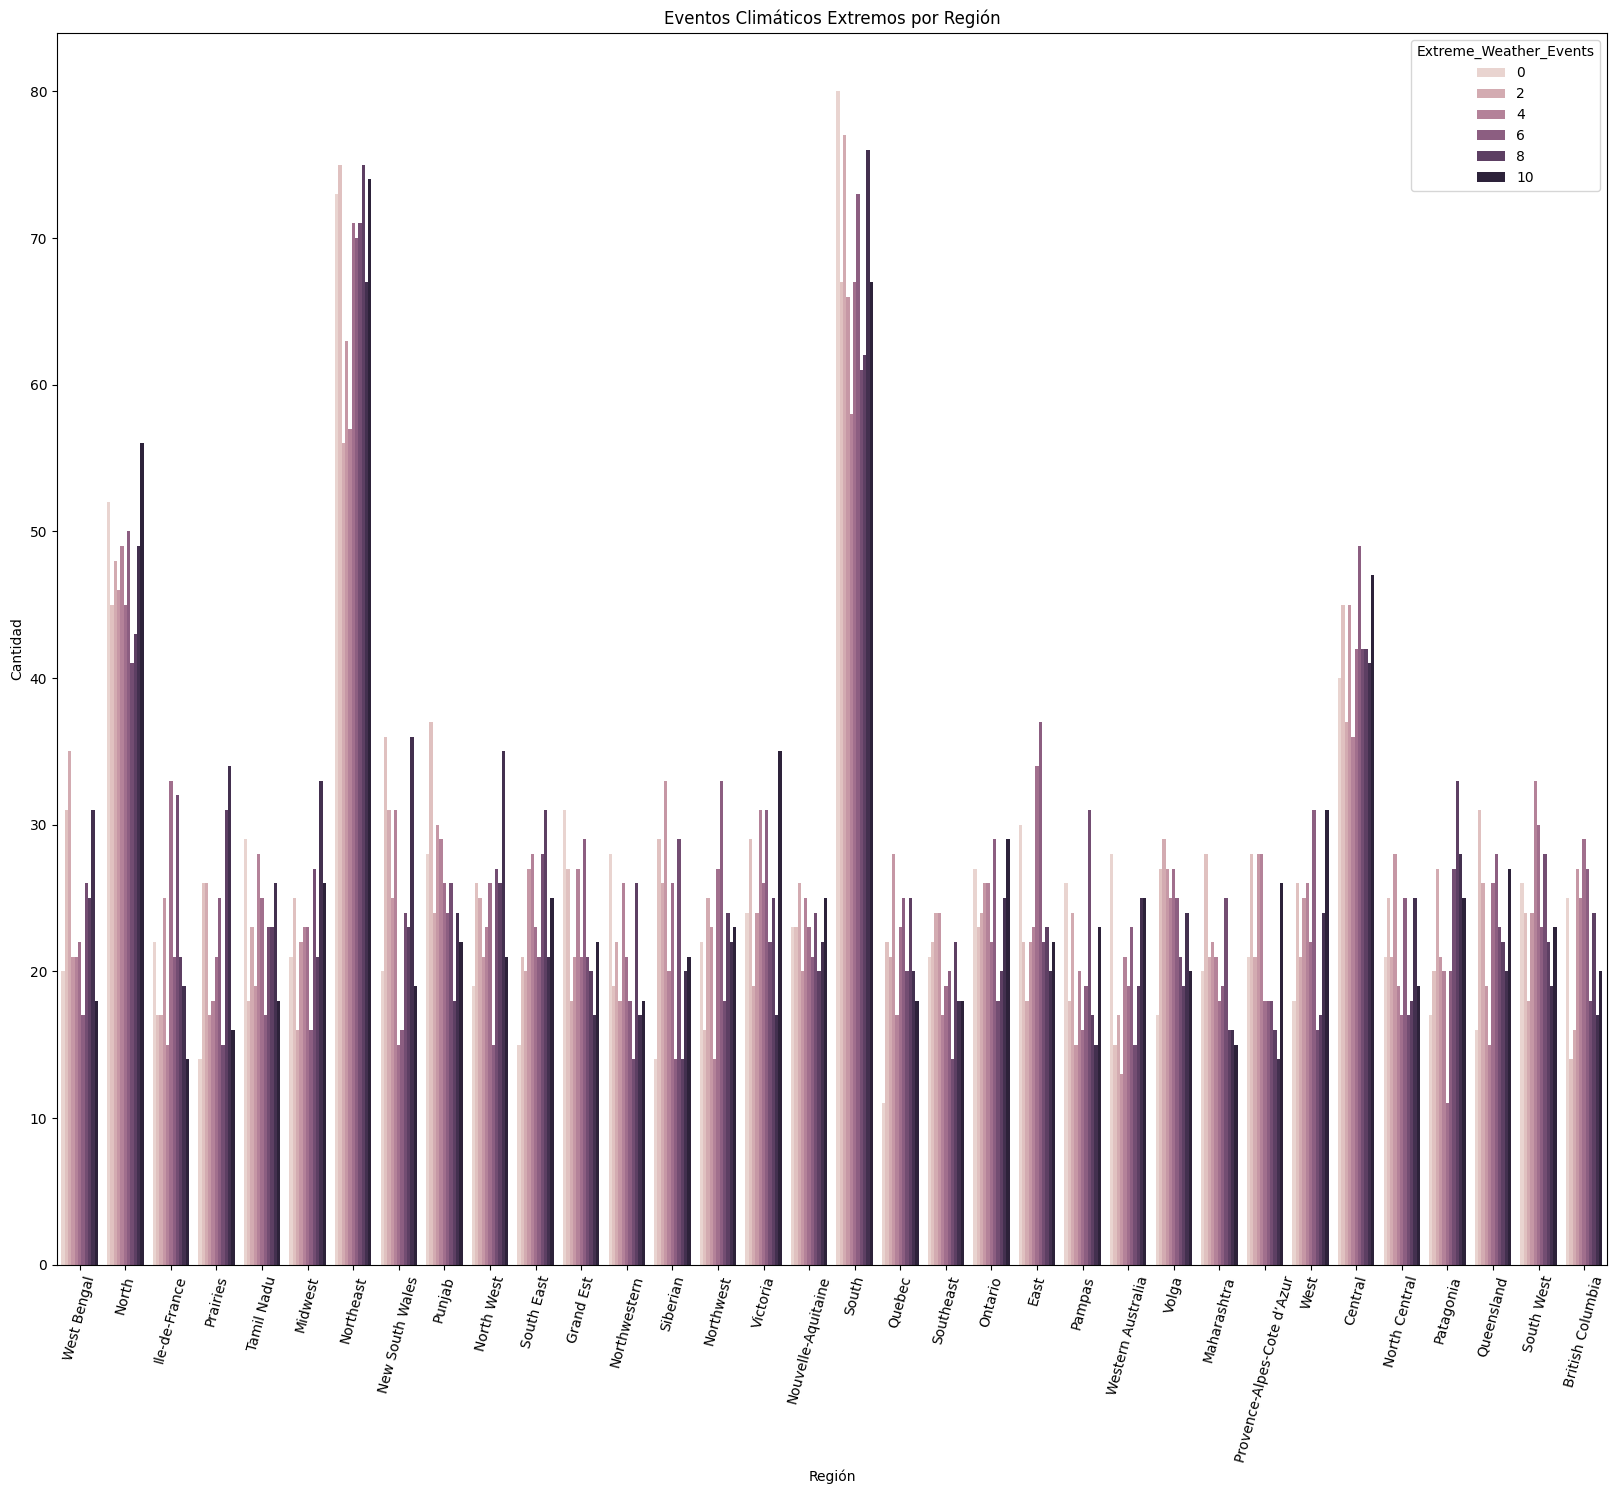

In [21]:
plt.figure(figsize=(20, 16))
sns.countplot(x='Region', hue='Extreme_Weather_Events', data=data)
plt.title('Eventos Climáticos Extremos por Región')
plt.xlabel('Región')
plt.ylabel('Cantidad')
plt.xticks(rotation=75)
plt.show()

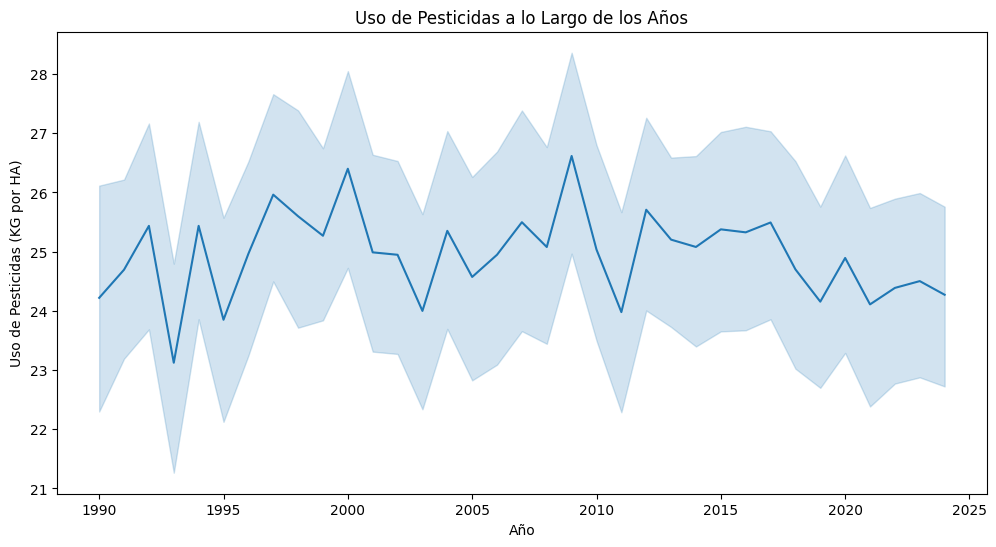

In [22]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Pesticide_Use_KG_per_HA', data=data)
plt.title('Uso de Pesticidas a lo Largo de los Años')
plt.xlabel('Año')
plt.ylabel('Uso de Pesticidas (KG por HA)')
plt.show()

<Axes: xlabel='Adaptation_Strategies', ylabel='Crop_Yield_MT_per_HA'>

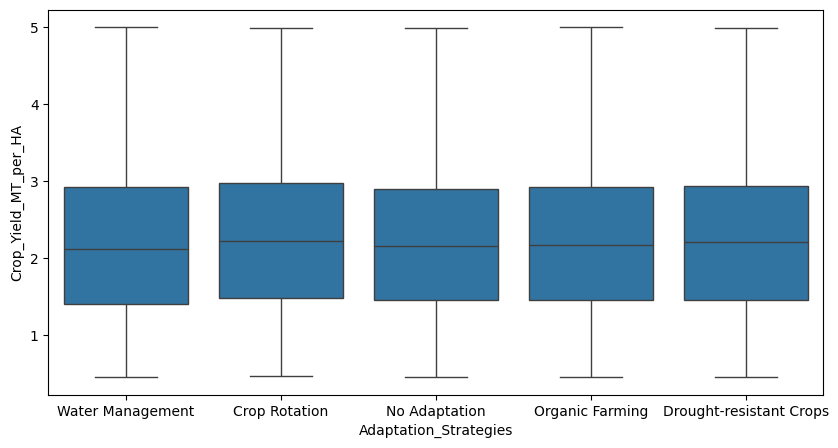

In [23]:
var = 'Adaptation_Strategies' 
data_v2 = pd.concat([data['Crop_Yield_MT_per_HA'], data[var]], axis = 1) 
plt.figure(figsize=(10,5))
sns.boxplot(x = var, y = 'Crop_Yield_MT_per_HA', data=data) 

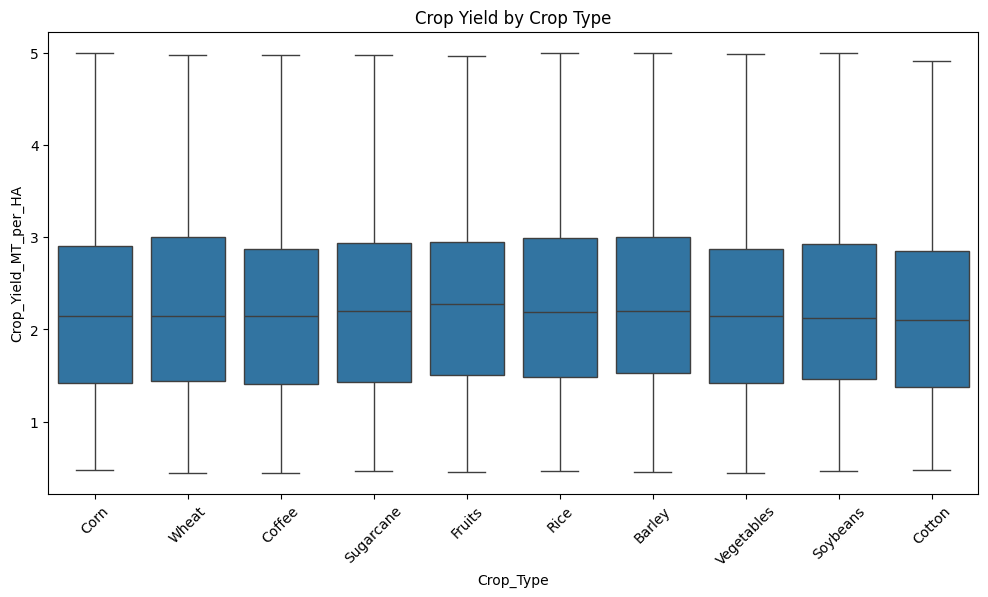

In [24]:
#  Boxplot for Crop Yield by Crop Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='Crop_Type', y='Crop_Yield_MT_per_HA', data=data)
plt.title('Crop Yield by Crop Type')
plt.xticks(rotation=45)
plt.show()